# Preprocessing DL — Version 2 (sans data leakage)
> **Corrections apportées :**
> - ✅ Suppression des sous-types de pannes (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) → élimine le data leakage
> - ✅ 6 features physiques uniquement
> - ✅ Métriques enrichies recommandées : F1, AUC-ROC, Recall

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
import joblib

## 1. Chargement des données

In [2]:
df = pd.read_csv('C:/Users/Administrator/Documents/projectsML/ML/data/raw/ai4i2020.csv')

print("Shape:", df.shape)
print(df.head())
print("\n#les valeurs manquantes")
print(df.isnull().sum())

Shape: (10000, 14)
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0  

## 2. Visualisation du déséquilibre

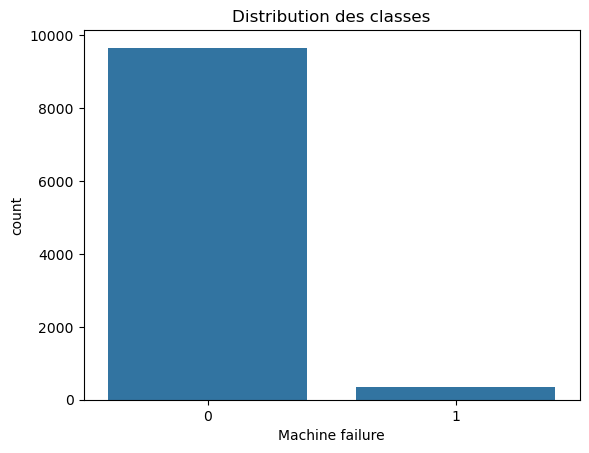

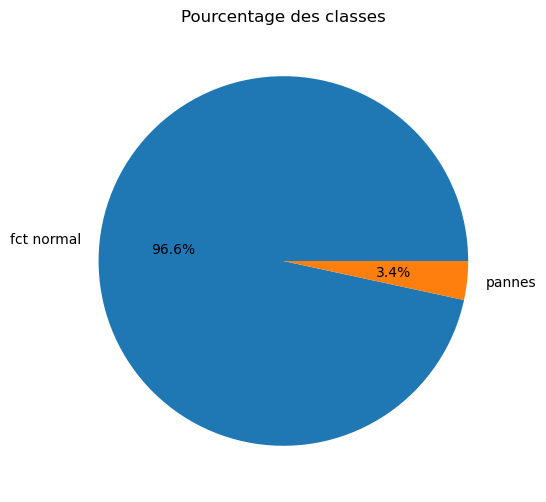

In [3]:
sns.countplot(x='Machine failure', data=df)
plt.title('Distribution des classes')
plt.show()

percentages = df['Machine failure'].value_counts(normalize=True) * 100
plt.figure(figsize=(6,6))
plt.pie(
    percentages,
    labels=['fct normal', 'pannes'],
    autopct='%1.1f%%'
)
plt.title('Pourcentage des classes')
plt.show()

## 3. Suppression des colonnes inutiles + sous-types de pannes

> ✅ **Correction v2** : `TWF`, `HDF`, `PWF`, `OSF`, `RNF` sont supprimées — elles causent un **data leakage direct** vers `Machine failure`.

In [4]:
# Suppression colonnes non informatives
df = df.drop(columns=['UDI', 'Product ID'])

# ✅ FIX data leakage : suppression des sous-types de pannes
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df = df.drop(columns=failure_cols)

print('Colonnes restantes :', df.columns.tolist())
print(df.head())

Colonnes restantes : ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  
0         42.8                0                0  
1         46.3                3                0  
2         49.4                5                0  
3         39.5                7                0  
4         40.0                9                0  


## 4. Encodage de la variable Type

In [5]:
mapping = {'L': 0, 'M': 1, 'H': 2}
df['Type'] = df['Type'].map(mapping)
print(df.head())

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     1                298.1                    308.6                    1551   
1     0                298.2                    308.7                    1408   
2     0                298.1                    308.5                    1498   
3     0                298.2                    308.6                    1433   
4     0                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  
0         42.8                0                0  
1         46.3                3                0  
2         49.4                5                0  
3         39.5                7                0  
4         40.0                9                0  


## 5. Visualisation après encodage

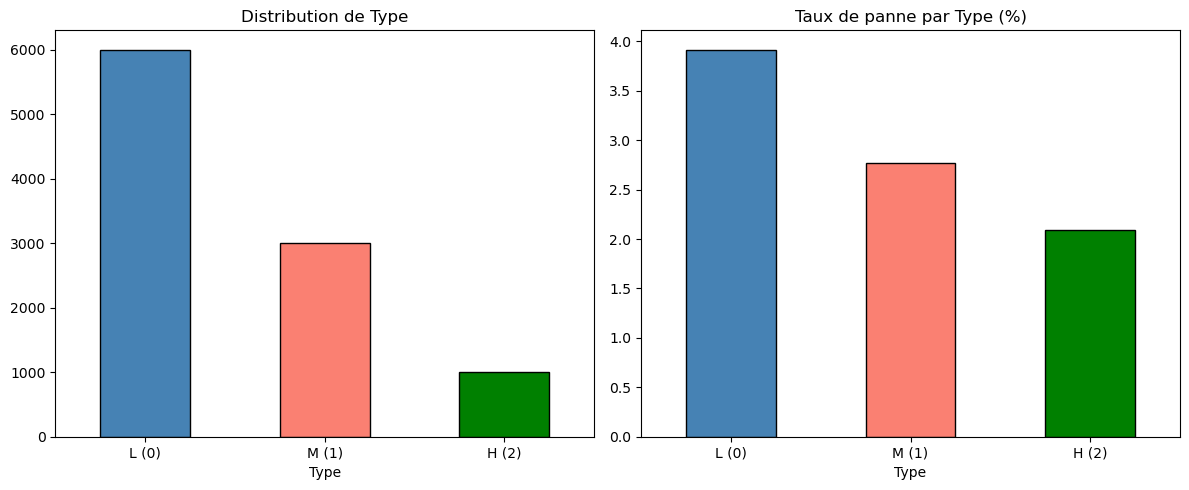

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Type'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'salmon', 'green'], edgecolor='black')
axes[0].set_title('Distribution de Type')
axes[0].set_xticklabels(['L (0)', 'M (1)', 'H (2)'], rotation=0)

(df.groupby('Type')['Machine failure'].mean() * 100).sort_index().plot(
    kind='bar', ax=axes[1],
    color=['steelblue', 'salmon', 'green'], edgecolor='black')
axes[1].set_title('Taux de panne par Type (%)')
axes[1].set_xticklabels(['L (0)', 'M (1)', 'H (2)'], rotation=0)

plt.tight_layout()
plt.show()

## 6. Matrice de corrélation (features réelles uniquement)

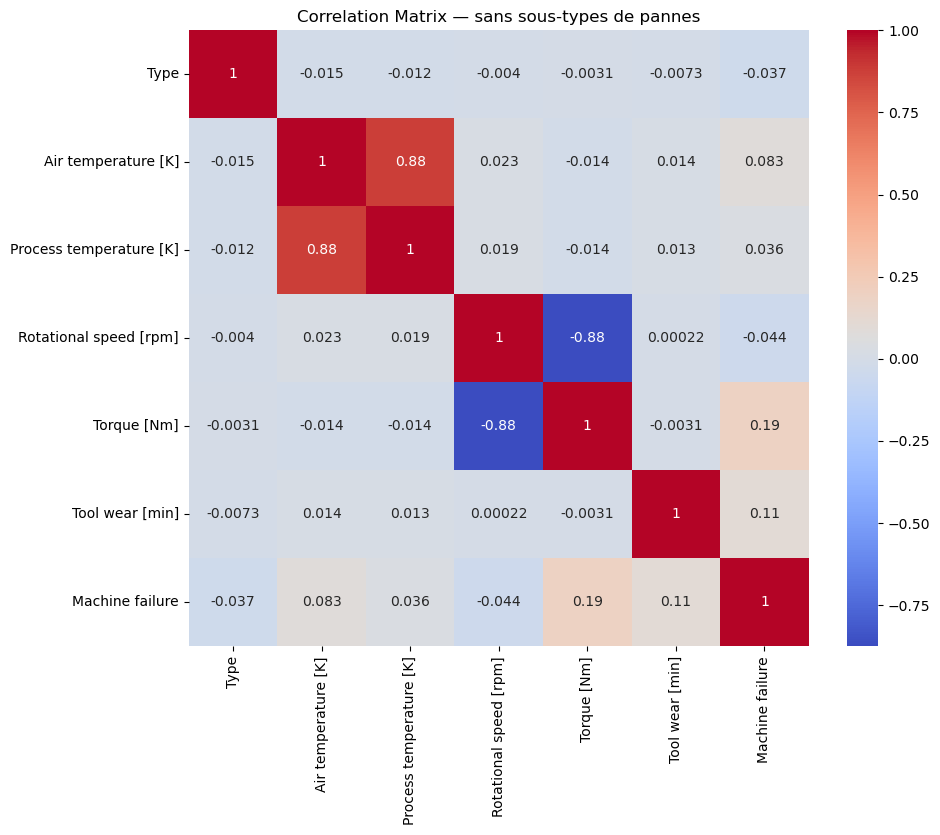

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix — sans sous-types de pannes')
plt.show()

## 7. Séparation Features / Target

In [8]:
# ✅ 6 features uniquement — sans data leakage
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

print('Features utilisées :', X.columns.tolist())
# Attendu : Type, Air temperature, Process temperature,
#            Rotational speed, Torque, Tool wear
print('Shape X:', X.shape, '| Shape y:', y.shape)

Features utilisées : ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Shape X: (10000, 6) | Shape y: (10000,)


## 8. Split Train / Validation / Test

In [9]:
# Step 1 : 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Step 2 : 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")

Train : (7000, 6) | Val : (1500, 6) | Test : (1500, 6)


## 9. Normalisation (MinMaxScaler)

In [10]:
scaler_dl = MinMaxScaler()
X_train_scaled = scaler_dl.fit_transform(X_train)
X_val_scaled   = scaler_dl.transform(X_val)
X_test_scaled  = scaler_dl.transform(X_test)

## 10. SMOTE — Rééquilibrage des classes (sur train uniquement)

In [11]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Avant SMOTE :", dict(pd.Series(y_train).value_counts()))
print("Après SMOTE :", dict(pd.Series(y_train_resampled).value_counts()))

Avant SMOTE : {0: np.int64(6763), 1: np.int64(237)}
Après SMOTE : {0: np.int64(6763), 1: np.int64(6763)}


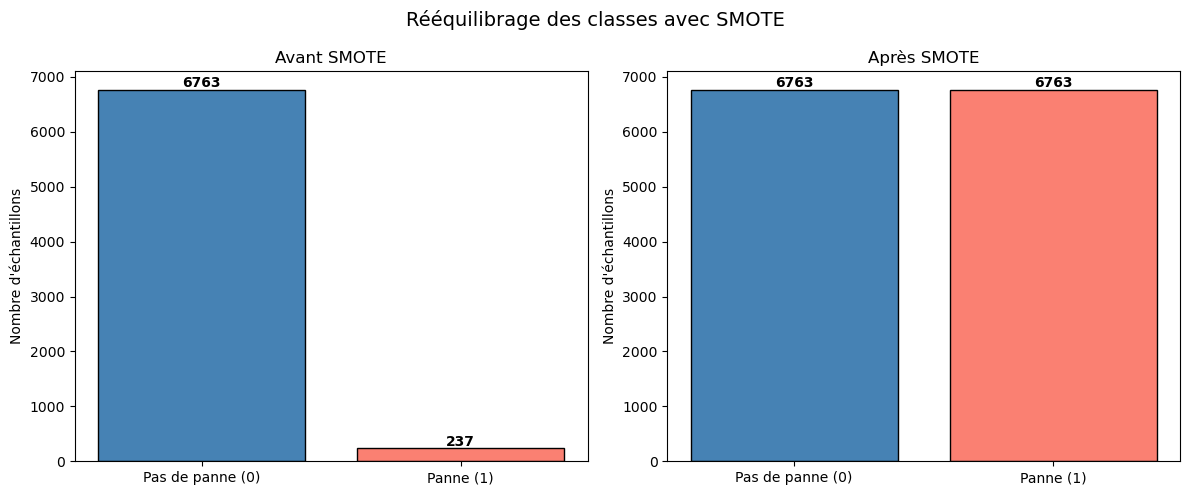

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Pas de panne (0)', 'Panne (1)'],
            y_train.value_counts().sort_index(),
            color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Avant SMOTE')
axes[0].set_ylabel("Nombre d'échantillons")
for i, v in enumerate(y_train.value_counts().sort_index()):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

after_counts = pd.Series(y_train_resampled).value_counts().sort_index()
axes[1].bar(['Pas de panne (0)', 'Panne (1)'],
            after_counts,
            color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Après SMOTE')
axes[1].set_ylabel("Nombre d'échantillons")
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Rééquilibrage des classes avec SMOTE', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Conversion en Tenseurs PyTorch

In [13]:
X_train_t = torch.FloatTensor(X_train_resampled)
X_val_t   = torch.FloatTensor(X_val_scaled)
X_test_t  = torch.FloatTensor(X_test_scaled)

y_train_t = torch.FloatTensor(y_train_resampled).unsqueeze(1)
y_val_t   = torch.FloatTensor(y_val.values).unsqueeze(1)
y_test_t  = torch.FloatTensor(y_test.values).unsqueeze(1)

print("Shapes :")
print("X_train_t :", X_train_t.shape)
print("X_val_t   :", X_val_t.shape)
print("X_test_t  :", X_test_t.shape)

Shapes :
X_train_t : torch.Size([13526, 6])
X_val_t   : torch.Size([1500, 6])
X_test_t  : torch.Size([1500, 6])


## 12. Sauvegarde des Tenseurs et du Scaler

In [14]:
BASE = 'C:/Users/Administrator/Documents/projectsML/ML/data/processed_forDL_v2/'

torch.save(X_train_t, BASE + 'X_train_dl.pt')
torch.save(X_val_t,   BASE + 'X_val_dl.pt')
torch.save(X_test_t,  BASE + 'X_test_dl.pt')

torch.save(y_train_t, BASE + 'y_train_dl.pt')
torch.save(y_val_t,   BASE + 'y_val_dl.pt')
torch.save(y_test_t,  BASE + 'y_test_dl.pt')

joblib.dump(scaler_dl, 'C:/Users/Administrator/Documents/projectsML/ML/models/scaler_dl_v2.pkl')

print("Tenseurs sauvegardés ✅")
print("Scaler DL v2 sauvegardé ✅")

Tenseurs sauvegardés ✅
Scaler DL v2 sauvegardé ✅


## 13. Récapitulatif du preprocessing

In [15]:
print("=" * 50)
print("PREPROCESSING DL v2 TERMINÉ ✅")
print("=" * 50)
print(f"\nFeatures utilisées ({X_train_t.shape[1]}) :")
print(X.columns.tolist())
print("\n⚠️  Colonnes exclues (data leakage) :")
print(['TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
print("\nShapes finales :")
print(f"  X_train : {X_train_t.shape}")
print(f"  X_val   : {X_val_t.shape}")
print(f"  X_test  : {X_test_t.shape}")
print("\n📊 Métriques recommandées pour évaluer le MLP :")
print("  - F1-score (macro ou weighted)")
print("  - AUC-ROC")
print("  - Recall (priorité : détecter les vraies pannes)")
print("  - Matrice de confusion")

PREPROCESSING DL v2 TERMINÉ ✅

Features utilisées (6) :
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

⚠️  Colonnes exclues (data leakage) :
['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Shapes finales :
  X_train : torch.Size([13526, 6])
  X_val   : torch.Size([1500, 6])
  X_test  : torch.Size([1500, 6])

📊 Métriques recommandées pour évaluer le MLP :
  - F1-score (macro ou weighted)
  - AUC-ROC
  - Recall (priorité : détecter les vraies pannes)
  - Matrice de confusion
